# Titanic - Machine Learning from Disaster

 ***Only the training set*** from: https://www.kaggle.com/competitions/titanic/data

Data Description:

survival	Survival	0 = No, 1 = Yes

pclass	Ticket class	1 = 1st, 2 = 2nd, 3 = 3rd

sex	Sex

Age	Age in years

sibsp	# of siblings / spouses aboard the Titanic

parch	# of parents / children aboard the Titanic

ticket	Ticket number

fare	Passenger fare

cabin	Cabin number

embarked	Port of Embarkation	C = Cherbourg, Q = Queenstown, S = Southampton


**Using NN to create three models that predicts which passengers survived the Titanic shipwreck**

### Data pre-processing

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [17]:
pd.read_csv("data/train.csv")

In [18]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [19]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


###Feature engineering

Feature engineering in data science refers to manipulation — addition, deletion, combination, mutation of the data set to improve machine learning model training, leading to better performance and greater accuracy.

From the columns that denote the number of sibilings and number of parents **defined a new column isAlone** which shows if the passenger has relatives on the boat. The column should contain 0s and 1s.

Additionally changed the **age column** such that the passengers are divided in five age groups: 0 for age<=16, 1 for 16<age<=32, 2 for 32<age<=48, 3 for 48<age<=64 and 4 for age>64.

In [20]:
df['isAlone'] = np.where((df['SibSp'] + df['Parch']) > 0, 0, 1)

In [21]:
df = df.drop(['SibSp', 'Parch'], axis=1)

In [22]:
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Age'] = df['Age'].astype(int)

/tmp/ipykernel_1528/3783943910.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [23]:
bins = [0, 16, 32, 48, 64, float('inf')]
labels = [0, 1, 2, 3, 4]
df['Age'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

In [24]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,isAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,1,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,2,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,1,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,2,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,2,373450,8.0500,NaN,S,1
...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,1,211536,13.0000,NaN,S,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,1,112053,30.0000,B42,S,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,1,W./C. 6607,23.4500,NaN,S,0
889,890,1,1,"Behr, Mr. Karl Howell",male,1,111369,30.0000,C148,C,1


In [25]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

In [26]:
from sklearn.model_selection import train_test_split
X = df[["Pclass", "Sex", "Age", "isAlone"]]
Y = df["Survived"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 0)

In [27]:
df = df.drop(['Name', 'Ticket', 'Cabin', 'Embarked', 'PassengerId'], axis=1)

In [28]:
df['Fare'].fillna(df['Fare'].mean(), inplace=True)

/tmp/ipykernel_1528/1367476775.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Fare'].fillna(df['Fare'].mean(), inplace=True)


In [29]:
df.head()

,Survived,Pclass,Sex,Age,Fare,isAlone
0,0,3,0,1,7.2500,0
1,1,1,1,2,71.2833,0
2,1,3,1,1,7.9250,1
3,1,1,1,2,53.1000,0
4,0,3,0,2,8.0500,1


In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [31]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Neural Network 1

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

#### Optimized number of epochs and batch size for NN1

(Tried different values for the epochs and batch size parameters and chose the optimal ones)

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Needed a wrapper class for the neural network models

https://adriangb.com/scikeras/stable/generated/scikeras.wrappers.KerasClassifier.html

In [ ]:
history1 = model.fit(X_train, Y_train, epochs=50, batch_size=32, verbose=1, validation_split=0.1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.6445 - loss: 0.2753 - val_accuracy: 0.6806 - val_loss: 0.1870
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7609 - loss: 0.1592 - val_accuracy: 0.7500 - val_loss: 0.1644
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7987 - loss: 0.1448 - val_accuracy: 0.7778 - val_loss: 0.1640
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8279 - loss: 0.1347 - val_accuracy: 0.7778 - val_loss: 0.1695
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8311 - loss: 0.1388 - val_accuracy: 0.7778 - val_loss: 0.1690
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8059 - loss: 0.1455 - val_accuracy: 0.7778 - val_loss: 0.1704
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8334 - loss: 0.1277 - val_accuracy: 0.7778 - val_loss: 0.1653
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8424 - loss: 0.1249 - val_accuracy: 0.7778 - val_l

### Neural Network 2

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

#### Optimized number of epochs and batch size for NN2

---



---



(Tried different values for the epochs and batch size parameters and chose the optimal ones)

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Needed a wrapper class for the neural network models

https://adriangb.com/scikeras/stable/generated/scikeras.wrappers.KerasClassifier.html

In [ ]:
history2 = model.fit(X_train, Y_train, epochs=15, batch_size=50,  verbose=1, validation_split=0.2)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8294 - loss: 0.1279 - val_accuracy: 0.8112 - val_loss: 0.1429
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8227 - loss: 0.1253 - val_accuracy: 0.8112 - val_loss: 0.1399
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8167 - loss: 0.1300 - val_accuracy: 0.8112 - val_loss: 0.1443
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8246 - loss: 0.1287 - val_accuracy: 0.8112 - val_loss: 0.1434
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8377 - loss: 0.1268 - val_accuracy: 0.8112 - val_loss: 0.1415
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8313 - loss: 0.1233 - val_accuracy: 0.8112 - val_loss: 0.1467
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8172 - loss: 0.1380 - val_accuracy: 0.8112 - val_loss: 0.1463
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8005 - loss: 0.1411 - val_accuracy: 0.8112 - val_

### Neural Network 3

In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])

#### Optimized number of epochs and batch size for NN3

(Tried different values for the epochs and batch size parameters and chose the optimal ones)

https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

Needed a wrapper class for the neural network models

https://adriangb.com/scikeras/stable/generated/scikeras.wrappers.KerasClassifier.html


In [ ]:
history3 = model.fit(X_train, Y_train, epochs=30, batch_size=9,  verbose=1, validation_split=0.2)

Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8180 - loss: 0.1273 - val_accuracy: 0.7972 - val_loss: 0.1467
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8359 - loss: 0.1257 - val_accuracy: 0.8112 - val_loss: 0.1402
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8197 - loss: 0.1330 - val_accuracy: 0.8112 - val_loss: 0.1468
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8269 - loss: 0.1324 - val_accuracy: 0.8112 - val_loss: 0.1451
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8179 - loss: 0.1349 - val_accuracy: 0.8112 - val_loss: 0.1539
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8317 - loss: 0.1337 - val_accuracy: 0.8112 - val_loss: 0.1489
Epoch 7/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8260 - loss: 0.1318 - val_accuracy: 0.8112 - val_loss: 0.1438
Epoch 8/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8363 - loss: 0.1219 - val_accuracy: 0.8112 - val_loss:

### Evaluated the three NNs - Visualization

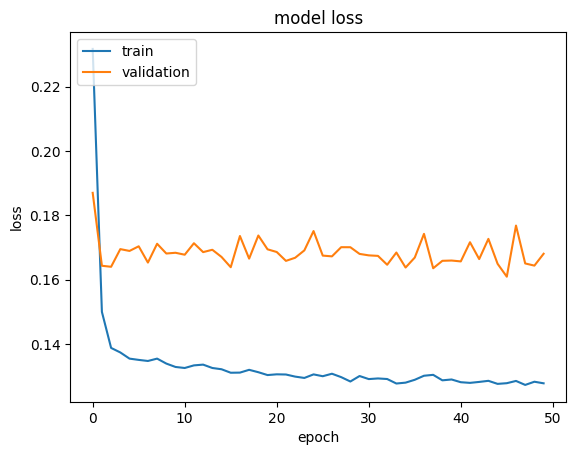

In [ ]:
import matplotlib.pyplot as plt

# "Loss"
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

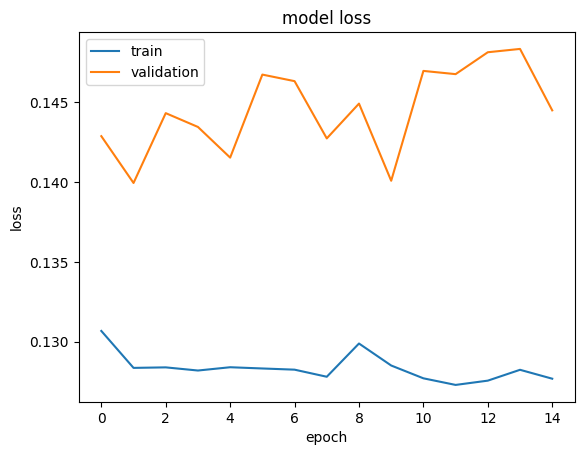

In [ ]:
import matplotlib.pyplot as plt

# "Loss"
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

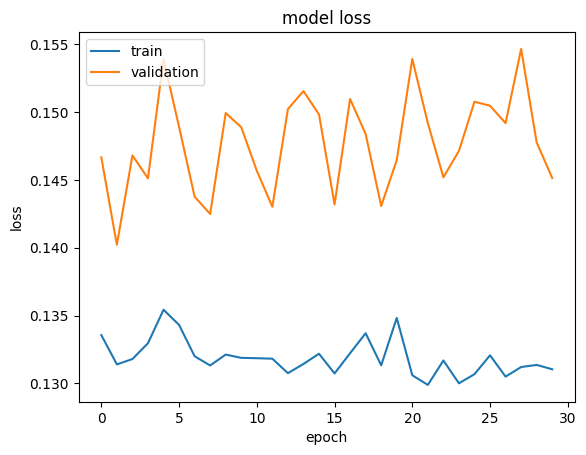

In [ ]:
import matplotlib.pyplot as plt

# "Loss"
plt.plot(history3.history['loss'])
plt.plot(history3.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## Results analysis

In [ ]:
y_pred = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [ ]:
#accuracy score
from sklearn.metrics import accuracy_score
ac=accuracy_score(Y_test.round(), y_pred.round())
print('accuracy of the model: ',ac)

accuracy of the model:  0.7932960893854749
